# Explore here

In [43]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [44]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"
df = pd.read_csv(url)
df.to_csv("../data/raw/data.csv", index=False)
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


El dataset contiene 891 registros, y tres columnas dos de modo object *package_name*, *review*, y  una int64 *polarity*. 
No existen valores nulos.


In [46]:
#Analisis de sentimientos y limpieza de texto 
df["package_name"] = df["package_name"].str.strip().str.lower()
df["review"] = df["review"].str.strip().str.lower()
df.columns = ["package_name", "review", "polarity"]

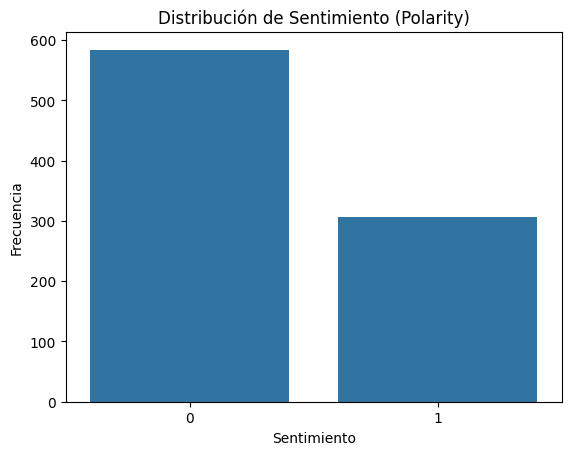

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de polaridad
sns.countplot(data=df, x='polarity')
plt.title("Distribución de Sentimiento (Polarity)")
plt.xlabel("Sentimiento")
plt.ylabel("Frecuencia")
plt.show()


El grafico nos indica la frecuencia de reseñas, donde 0 son la polaridad negativa y 1 las positivas. La mayoria de las reseñas tiene polaridad 0, es decir que los comentarios neutros o negativos son los mas frecuentes. Las reseñas positivas nos indican o que existe un sesgo o que hay una tendencia real en las opiniones por el usuario. 

In [48]:
# Separar características y variable objetivo
X = df.drop(columns=["polarity"])
y = df["polarity"]

# Dividir en entrenamiento test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# tamaño 
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 2), Test: (179, 2)


In [49]:
# CountVectorizer para transformar el texto en datos numéricos
vec_model = CountVectorizer(stop_words="english")

# Aplicamos la transformación de datos y prueba
X_train_vec = vec_model.fit_transform(X_train["review"]).toarray()
X_test_vec = vec_model.transform(X_test["review"]).toarray()
X_test_vec


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(179, 3272))

In [50]:
#Ejecutar el Naives

# Modelos
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# Entrenamiento
gnb.fit(X_train_vec, y_train)
mnb.fit(X_train_vec, y_train)
bnb.fit(X_train_vec, y_train)

# Prediccion
y_pred_gnb = gnb.predict(X_test_vec)
y_pred_mnb = mnb.predict(X_test_vec)
y_pred_bnb = bnb.predict(X_test_vec)

# Evaluar cada modelo
acc_gnb = accuracy_score(y_test, y_pred_gnb)
acc_mnb = accuracy_score(y_test, y_pred_mnb)
acc_bnb = accuracy_score(y_test, y_pred_bnb)

print(f"Precisión GaussianNB: {acc_gnb:.2f}")
print(f"Precisión MultinomialNB: {acc_mnb:.2f}")
print(f"Precisión BernoulliNB: {acc_bnb:.2f}")


Precisión GaussianNB: 0.82
Precisión MultinomialNB: 0.85
Precisión BernoulliNB: 0.78


MultinomialNB tiene mayor precision con el 85% lo que dice que adapta mejor mejor a datos de texto. GaussianNB se adapta bien pero suele ser mas efectivo en datos continuos, Y BernoullinNB es el mas baja lo que nos dice que la tranformacion binaria no es optima para esta tarea. 

In [51]:
# Mejor modelo 
best_model = MultinomialNB()
best_model.fit(X_train_vec, y_train)

y_pred_best = best_model.predict(X_test_vec)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Precisión del mejor modelo Naive Bayes: {accuracy_best:.2f}")


Precisión del mejor modelo Naive Bayes: 0.85


In [52]:
#Evaluar otros modelos:

#Entrenar Random Forest
RF_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
RF_model.fit(X_train_vec, y_train)

# Evaluar precisión en test
y_pred_rf = RF_model.predict(X_test_vec)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Precisión de Random Forest: {accuracy_rf:.2f}")


Precisión de Random Forest: 0.69


In [53]:
joblib.dump(best_model if accuracy_best > accuracy_rf else RF_model, "optimized_model.pkl")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [54]:
# Definir el modelo con regularización
tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
tree.fit(X_train_vec, y_train)

# Predicción
y_pred_tree = tree.predict(X_test_vec)

# Evaluar rendimiento
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Precisión del Árbol Regularizado: {acc_tree:.2f}")


Precisión del Árbol Regularizado: 0.74


In [55]:
# Regresión logística
RL_model = LogisticRegression(random_state=42)
RL_model.fit(X_train_vec, y_train)

# Predicción y evaluación
y_pred_RL = RL_model.predict(X_test_vec)
accuracy_RL = accuracy_score(y_test, y_pred_RL)

print(f"Precisión Regresión Logística: {accuracy_RL:.2f}")


Precisión Regresión Logística: 0.83


Precisión de los modelos: [0.6871508379888268, 0.7374301675977654, 0.8324022346368715]


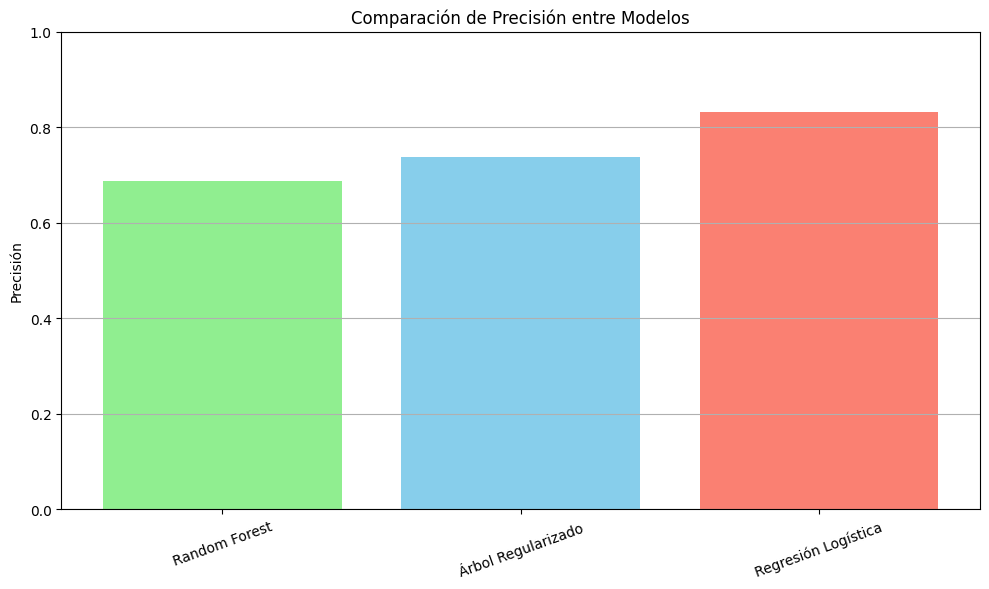

In [56]:
# Modelos
model_names = ['Random Forest', 'Árbol Regularizado', 'Regresión Logística']

# Precisiones
accuracies = [accuracy_rf, acc_tree, accuracy_RL]
print(f"Precisión de los modelos: {accuracies}")

x = np.arange(len(model_names))

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(x, accuracies, color=['lightgreen', 'skyblue', 'salmon'])
plt.xticks(x, model_names, rotation=20)
plt.ylabel("Precisión")
plt.title("Comparación de Precisión entre Modelos")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()


Regresión Logística tiene la mayor precisión, lo que nos dice que los datos tienen una relación lineal clara que facilita la clasificación. 
Árbol Regularizado, tiene buen rendimiento, pero es menos preciso que la Regresión Logística.
Random Forest, tiene una precisión más baja, lo que podría indicar que el modelo no está aprovechando bien la combinación de árboles o necesita más ajuste.